In [1]:
%pip install "numpy<2"

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install -U numexpr bottleneck

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv("../datasets/raw/CKD_NHANES_2021_2023.csv")

df.head()

,participant_id,age,gender,ethnicity,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,...,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,insulin_use,diabetes_pills,ever_smoked,current_smoker,egfr,ckd_stage,ckd_present
0,130378.0,43.0,Male,Non-Hispanic Asian,5.0,5.00,27.0,86.9,179.5,135.0,...,23.12,17.00,2.0,NaN,NaN,1.0,3.0,112.61,No CKD,0
1,130379.0,66.0,Male,Non-Hispanic White,5.0,5.00,33.5,101.8,174.2,121.0,...,4.25,6.64,2.0,NaN,NaN,1.0,3.0,97.98,No CKD,0
2,130380.0,44.0,Female,Other Hispanic,3.0,1.41,29.7,69.4,152.9,111.0,...,12.43,7.92,1.0,2.0,1.0,2.0,NaN,111.69,No CKD,0
3,130381.0,5.0,Female,Other/Multiracial,NaN,1.53,23.8,34.3,120.1,NaN,...,16.12,7.75,2.0,NaN,NaN,NaN,NaN,NaN,Unknown,1
4,130382.0,2.0,Male,Non-Hispanic White,NaN,3.60,NaN,13.6,NaN,NaN,...,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,Unknown,1


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 11933
Number of columns: 29


In [6]:
df.columns

Index(['participant_id', 'age', 'gender', 'ethnicity', 'education_level',
       'poverty_income_ratio', 'bmi', 'weight_kg', 'height_cm', 'bp_systolic',
       'bp_diastolic', 'serum_creatinine', 'blood_urea_nitrogen',
       'albumin_serum', 'phosphorus', 'bicarbonate', 'calcium', 'uric_acid',
       'urine_creatinine', 'urine_albumin', 'albumin_creatinine_ratio',
       'diabetes_diagnosed', 'insulin_use', 'diabetes_pills', 'ever_smoked',
       'current_smoker', 'egfr', 'ckd_stage', 'ckd_present'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11933 entries, 0 to 11932
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   participant_id            11933 non-null  float64
 1   age                       11933 non-null  float64
 2   gender                    11933 non-null  str    
 3   ethnicity                 11933 non-null  str    
 4   education_level           7794 non-null   float64
 5   poverty_income_ratio      9892 non-null   float64
 6   bmi                       8471 non-null   float64
 7   weight_kg                 8754 non-null   float64
 8   height_cm                 8499 non-null   float64
 9   bp_systolic               7517 non-null   float64
 10  bp_diastolic              7517 non-null   float64
 11  serum_creatinine          6326 non-null   float64
 12  blood_urea_nitrogen       6326 non-null   float64
 13  albumin_serum             6366 non-null   float64
 14  phosphorus       

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
participant_id,11933.0,136344.000000,3444.904716,1.303780e+05,133361.0000,136344.00,139327.00,142310.00
age,11933.0,38.317858,25.601990,5.397605e-79,13.0000,37.00,62.00,80.00
education_level,7794.0,3.804978,1.153750,1.000000e+00,3.0000,4.00,5.00,9.00
poverty_income_ratio,9892.0,2.708174,1.670119,5.397605e-79,1.1800,2.50,4.50,5.00
bmi,8471.0,27.246665,8.137781,1.110000e+01,21.6000,26.40,31.70,74.80
weight_kg,8754.0,70.549037,30.389021,2.700000e+00,54.2000,71.70,89.10,248.20
height_cm,8499.0,159.664549,19.864943,7.910000e+01,154.4000,163.60,172.10,200.70
bp_systolic,7517.0,119.288546,18.561052,6.100000e+01,106.0000,117.00,130.00,232.00
bp_diastolic,7517.0,72.748038,11.895572,3.300000e+01,64.0000,72.00,80.00,142.00
serum_creatinine,6326.0,0.872828,0.385498,3.300000e-01,0.7000,0.83,0.98,15.17


In [9]:
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    print("\n", "="*50)
    print(col)
    print(df[col].value_counts(dropna=False))


gender
gender
Female    6358
Male      5575
Name: count, dtype: int64

ethnicity
ethnicity
Non-Hispanic White    6217
Non-Hispanic Black    1597
Other Hispanic        1373
Mexican American      1117
Other/Multiracial      948
Non-Hispanic Asian     681
Name: count, dtype: int64

ckd_stage
ckd_stage
Unknown                         5607
No CKD                          3592
Stage 2 (Mildly Decreased)      1875
Stage 1 (Kidney Damage)          382
Stage 3a (Mild-Moderate)         341
Stage 3b (Moderate-Severe)        97
Stage 4 (Severely Decreased)      28
Stage 5 (Kidney Failure)          11
Name: count, dtype: int64


C:\Users\JAYASHREE\AppData\Local\Temp\ipykernel_6172\3128598854.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include='object').columns


In [10]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': df.isnull().mean() * 100
})

missing = missing.sort_values(
    by='Missing Percentage',
    ascending=False
)

missing

,Missing Count,Missing Percentage
insulin_use,10852,90.941088
diabetes_pills,9652,80.884941
current_smoker,8690,72.823263
phosphorus,5611,47.020867
bicarbonate,5608,46.995726
egfr,5607,46.987346
serum_creatinine,5607,46.987346
blood_urea_nitrogen,5607,46.987346
uric_acid,5604,46.962206
calcium,5571,46.685662


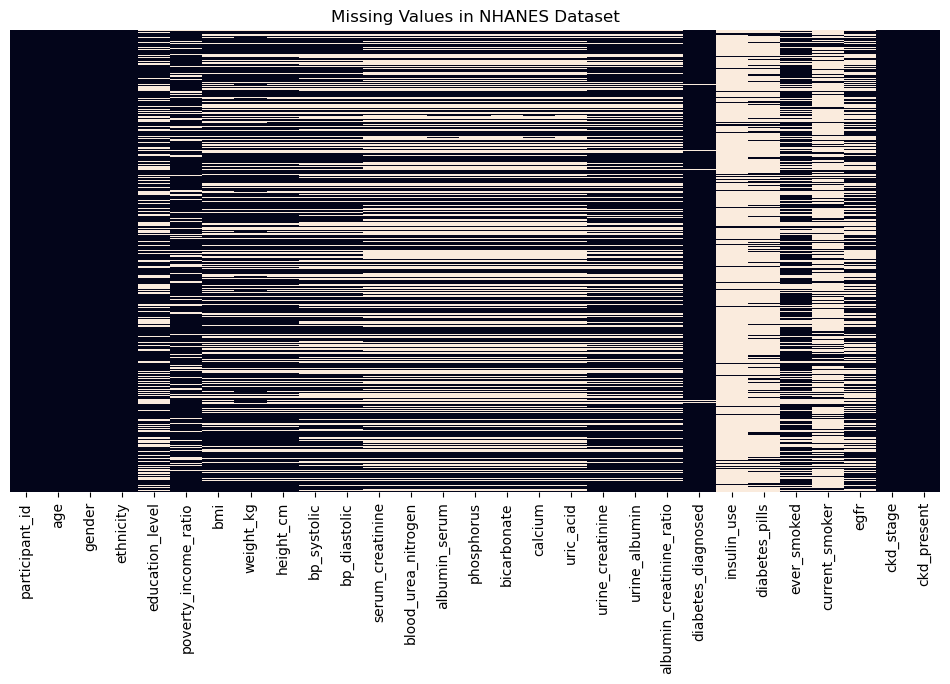

In [11]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values in NHANES Dataset")
plt.show()

In [12]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [13]:
print("Total records:", len(df))
print("Unique participant IDs:", df['participant_id'].nunique())

Total records: 11933
Unique participant IDs: 11933


In [14]:
print(df['ckd_present'].value_counts())

ckd_present
1    8341
0    3592
Name: count, dtype: int64


In [15]:
pd.crosstab(
    df['ckd_stage'],
    df['ckd_present'],
    margins=True
)

ckd_present,0,1,All
ckd_stage,,,
No CKD,3592,0,3592
Stage 1 (Kidney Damage),0,382,382
Stage 2 (Mildly Decreased),0,1875,1875
Stage 3a (Mild-Moderate),0,341,341
Stage 3b (Moderate-Severe),0,97,97
Stage 4 (Severely Decreased),0,28,28
Stage 5 (Kidney Failure),0,11,11
Unknown,0,5607,5607
All,3592,8341,11933


In [16]:
df.groupby('ckd_present')['egfr'].describe()

,count,mean,std,min,25%,50%,75%,max
ckd_present,,,,,,,,
0,3592.0,111.371837,15.502139,90.00,98.6200,108.00,121.965,178.43
1,2734.0,77.191800,20.615540,3.51,65.8225,77.63,86.740,153.77


In [17]:
selected_columns = [
    'age',
    'gender',
    'ethnicity',
    'bmi',
    'bp_systolic',
    'bp_diastolic',
    'serum_creatinine',
    'blood_urea_nitrogen',
    'albumin_serum',
    'phosphorus',
    'bicarbonate',
    'calcium',
    'uric_acid',
    'urine_albumin',
    'urine_creatinine',
    'albumin_creatinine_ratio',
    'diabetes_diagnosed',
    'ever_smoked',
    'ckd_present'
]

nhanes_model = df[selected_columns].copy()

nhanes_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 11933 entries, 0 to 11932
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       11933 non-null  float64
 1   gender                    11933 non-null  str    
 2   ethnicity                 11933 non-null  str    
 3   bmi                       8471 non-null   float64
 4   bp_systolic               7517 non-null   float64
 5   bp_diastolic              7517 non-null   float64
 6   serum_creatinine          6326 non-null   float64
 7   blood_urea_nitrogen       6326 non-null   float64
 8   albumin_serum             6366 non-null   float64
 9   phosphorus                6322 non-null   float64
 10  bicarbonate               6325 non-null   float64
 11  calcium                   6362 non-null   float64
 12  uric_acid                 6329 non-null   float64
 13  urine_albumin             8153 non-null   float64
 14  urine_creatinine 

In [18]:
nhanes_model.head()


,age,gender,ethnicity,bmi,bp_systolic,bp_diastolic,serum_creatinine,blood_urea_nitrogen,albumin_serum,phosphorus,bicarbonate,calcium,uric_acid,urine_albumin,urine_creatinine,albumin_creatinine_ratio,diabetes_diagnosed,ever_smoked,ckd_present
0,43.0,Male,Non-Hispanic Asian,27.0,135.0,98.0,0.80,11.0,4.3,3.7,24.0,9.6,5.1,23.12,136.0,17.00,2.0,1.0,0
1,66.0,Male,Non-Hispanic White,33.5,121.0,84.0,0.79,24.0,3.9,3.2,25.0,9.4,8.5,4.25,64.0,6.64,2.0,1.0,0
2,44.0,Female,Other Hispanic,29.7,111.0,79.0,0.64,10.0,3.7,3.8,25.0,9.4,4.4,12.43,157.0,7.92,1.0,2.0,0
3,5.0,Female,Other/Multiracial,23.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.12,208.0,7.75,2.0,NaN,1
4,2.0,Male,Non-Hispanic White,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,1


In [19]:
nhanes_model.shape

(11933, 19)

In [20]:
nhanes_model.isnull().sum().sort_values(ascending=False)

phosphorus                  5611
bicarbonate                 5608
serum_creatinine            5607
blood_urea_nitrogen         5607
uric_acid                   5604
calcium                     5571
albumin_serum               5567
bp_systolic                 4416
bp_diastolic                4416
ever_smoked                 3798
albumin_creatinine_ratio    3780
urine_albumin               3780
urine_creatinine            3779
bmi                         3462
diabetes_diagnosed           193
age                            0
gender                         0
ethnicity                      0
ckd_present                    0
dtype: int64

In [21]:
nhanes_model['missing_lab_count'] = nhanes_model[
    [
        'serum_creatinine',
        'blood_urea_nitrogen',
        'albumin_serum',
        'phosphorus',
        'bicarbonate',
        'calcium',
        'uric_acid'
    ]
].isnull().sum(axis=1)

nhanes_model['missing_lab_count'].value_counts().sort_index()

missing_lab_count
0    6304
1      21
3       3
4      14
5      24
7    5567
Name: count, dtype: int64

In [22]:
complete_lab_patients = (
    nhanes_model['missing_lab_count'] == 0
).sum()

print("Patients with all kidney labs available:", complete_lab_patients)
print(
    "Percentage:",
    round(complete_lab_patients / len(nhanes_model) * 100, 2),
    "%"
)

Patients with all kidney labs available: 6304
Percentage: 52.83 %


In [23]:
pd.crosstab(
    nhanes_model['missing_lab_count'],
    nhanes_model['ckd_present'],
    normalize='index'
).round(3)

ckd_present,0,1
missing_lab_count,,
0,0.568,0.432
1,0.429,0.571
3,0.333,0.667
4,0.071,0.929
5,0.000,1.000
7,0.000,1.000


In [24]:
nhanes_model.groupby(
    'missing_lab_count'
)['age'].describe()

,count,mean,std,min,25%,50%,75%,max
missing_lab_count,,,,,,,,
0,6304.0,48.609930,20.717955,1.200000e+01,31.00,52.0,66.0,80.0
1,21.0,51.095238,17.002661,2.100000e+01,37.00,55.0,66.0,78.0
3,3.0,55.000000,22.338308,3.000000e+01,46.00,62.0,67.5,73.0
4,14.0,39.928571,18.971494,1.600000e+01,23.75,41.0,52.5,72.0
5,24.0,45.625000,19.942989,1.600000e+01,28.25,52.5,63.0,71.0
7,5567.0,26.570505,25.619574,5.397605e-79,6.00,14.0,46.0,80.0


In [25]:
nhanes_model[
    nhanes_model['serum_creatinine'].isnull()
][
    ['age', 'gender', 'bmi', 'bp_systolic', 'serum_creatinine', 'ckd_present']
].head(20)

,age,gender,bmi,bp_systolic,serum_creatinine,ckd_present
3,5.0,Female,23.8,NaN,NaN,1
4,2.0,Male,NaN,NaN,NaN,1
5,3.0,Female,NaN,NaN,NaN,1
6,43.0,Male,NaN,NaN,NaN,1
7,65.0,Female,NaN,NaN,NaN,1
10,27.0,Female,43.7,130.0,NaN,1
11,59.0,Male,28.0,145.0,NaN,1
17,33.0,Female,54.6,112.0,NaN,1
19,67.0,Female,49.7,157.0,NaN,1
23,18.0,Male,28.3,NaN,NaN,1


In [26]:
complete_cohort = nhanes_model[
    nhanes_model['missing_lab_count'] == 0
].copy()

print("Shape:", complete_cohort.shape)

print("\nCKD distribution:")
print(complete_cohort['ckd_present'].value_counts())

print("\nCKD percentage:")
print(
    complete_cohort['ckd_present']
    .value_counts(normalize=True)
    .round(3)
)

Shape: (6304, 20)

CKD distribution:
ckd_present
0    3581
1    2723
Name: count, dtype: int64

CKD percentage:
ckd_present
0    0.568
1    0.432
Name: proportion, dtype: float64


In [27]:
complete_cohort.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,6304.0,NaN,NaN,NaN,48.60993,20.717955,12.0,31.0,52.0,66.0,80.0
gender,6304,2,Female,3411,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ethnicity,6304,6,Non-Hispanic White,3596,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,6224.0,NaN,NaN,NaN,29.083419,7.3641,12.9,24.0,27.8,32.9,74.8
bp_systolic,6112.0,NaN,NaN,NaN,120.738056,18.169485,61.0,108.0,118.0,131.0,232.0
bp_diastolic,6112.0,NaN,NaN,NaN,73.759162,11.54506,34.0,66.0,73.0,81.0,142.0
serum_creatinine,6304.0,NaN,NaN,NaN,0.873025,0.385984,0.33,0.7,0.83,0.98,15.17
blood_urea_nitrogen,6304.0,NaN,NaN,NaN,14.660692,5.756953,4.0,11.0,14.0,17.0,74.0
albumin_serum,6304.0,NaN,NaN,NaN,4.099064,0.355743,2.2,3.9,4.1,4.3,5.5
phosphorus,6304.0,NaN,NaN,NaN,3.607995,0.569537,1.6,3.2,3.6,3.9,7.0


In [28]:
categorical_columns = [
    'gender',
    'ethnicity',
    'diabetes_diagnosed',
    'ever_smoked'
]

for col in categorical_columns:
    print("\n", "=" * 50)
    print(col)
    print(complete_cohort[col].value_counts(dropna=False))


gender
gender
Female    3411
Male      2893
Name: count, dtype: int64

ethnicity
ethnicity
Non-Hispanic White    3596
Non-Hispanic Black     751
Other Hispanic         693
Mexican American       506
Other/Multiracial      411
Non-Hispanic Asian     347
Name: count, dtype: int64

diabetes_diagnosed
diabetes_diagnosed
2.0    5337
1.0     763
3.0     203
9.0       1
Name: count, dtype: int64

ever_smoked
ever_smoked
2.0    3393
1.0    2235
NaN     669
9.0       4
7.0       3
Name: count, dtype: int64


In [29]:
complete_cohort.isnull().sum().sort_values(ascending=False)

ever_smoked                 669
bp_systolic                 192
bp_diastolic                192
albumin_creatinine_ratio    123
urine_albumin               123
urine_creatinine            122
bmi                          80
age                           0
uric_acid                     0
ckd_present                   0
diabetes_diagnosed            0
bicarbonate                   0
calcium                       0
gender                        0
phosphorus                    0
albumin_serum                 0
blood_urea_nitrogen           0
serum_creatinine              0
ethnicity                     0
missing_lab_count             0
dtype: int64

In [30]:
for col in [
    'diabetes_diagnosed',
    'ever_smoked'
]:
    print("\n", col)
    print(sorted(complete_cohort[col].dropna().unique()))


 diabetes_diagnosed
[1.0, 2.0, 3.0, 9.0]

 ever_smoked
[1.0, 2.0, 7.0, 9.0]


In [31]:
# Remove helper column
complete_cohort = complete_cohort.drop(
    columns=['missing_lab_count']
)

# Clean diabetes
complete_cohort['diabetes_diagnosed'] = (
    complete_cohort['diabetes_diagnosed']
    .replace({
        1.0: 1,
        2.0: 0,
        3.0: 0,
        7.0: np.nan,
        9.0: np.nan
    })
)

# Drop smoking for now
complete_cohort = complete_cohort.drop(
    columns=['ever_smoked']
)

print(complete_cohort.shape)
print(complete_cohort['diabetes_diagnosed'].value_counts(dropna=False))

(6304, 18)
diabetes_diagnosed
0.0    5540
1.0     763
NaN       1
Name: count, dtype: int64


In [32]:
complete_cohort.isnull().sum().sort_values(ascending=False)

bp_systolic                 192
bp_diastolic                192
albumin_creatinine_ratio    123
urine_albumin               123
urine_creatinine            122
bmi                          80
diabetes_diagnosed            1
age                           0
calcium                       0
uric_acid                     0
phosphorus                    0
bicarbonate                   0
gender                        0
albumin_serum                 0
blood_urea_nitrogen           0
serum_creatinine              0
ethnicity                     0
ckd_present                   0
dtype: int64

In [33]:
numeric_cols = [
    'bmi',
    'bp_systolic',
    'bp_diastolic',
    'urine_albumin',
    'urine_creatinine',
    'albumin_creatinine_ratio'
]

for col in numeric_cols:
    complete_cohort[col] = complete_cohort[col].fillna(
        complete_cohort[col].median()
    )

In [34]:
complete_cohort = complete_cohort.dropna(
    subset=['diabetes_diagnosed']
)

In [35]:
print("Shape:", complete_cohort.shape)

print("\nRemaining missing values:")
print(complete_cohort.isnull().sum().sort_values(ascending=False))

Shape: (6303, 18)

Remaining missing values:
age                         0
gender                      0
diabetes_diagnosed          0
albumin_creatinine_ratio    0
urine_creatinine            0
urine_albumin               0
uric_acid                   0
calcium                     0
bicarbonate                 0
phosphorus                  0
albumin_serum               0
blood_urea_nitrogen         0
serum_creatinine            0
bp_diastolic                0
bp_systolic                 0
bmi                         0
ethnicity                   0
ckd_present                 0
dtype: int64


In [36]:
print(complete_cohort['ckd_present'].value_counts())
print(complete_cohort['ckd_present'].value_counts(normalize=True) * 100)

ckd_present
0    3580
1    2723
Name: count, dtype: int64
ckd_present
0    56.79835
1    43.20165
Name: proportion, dtype: float64


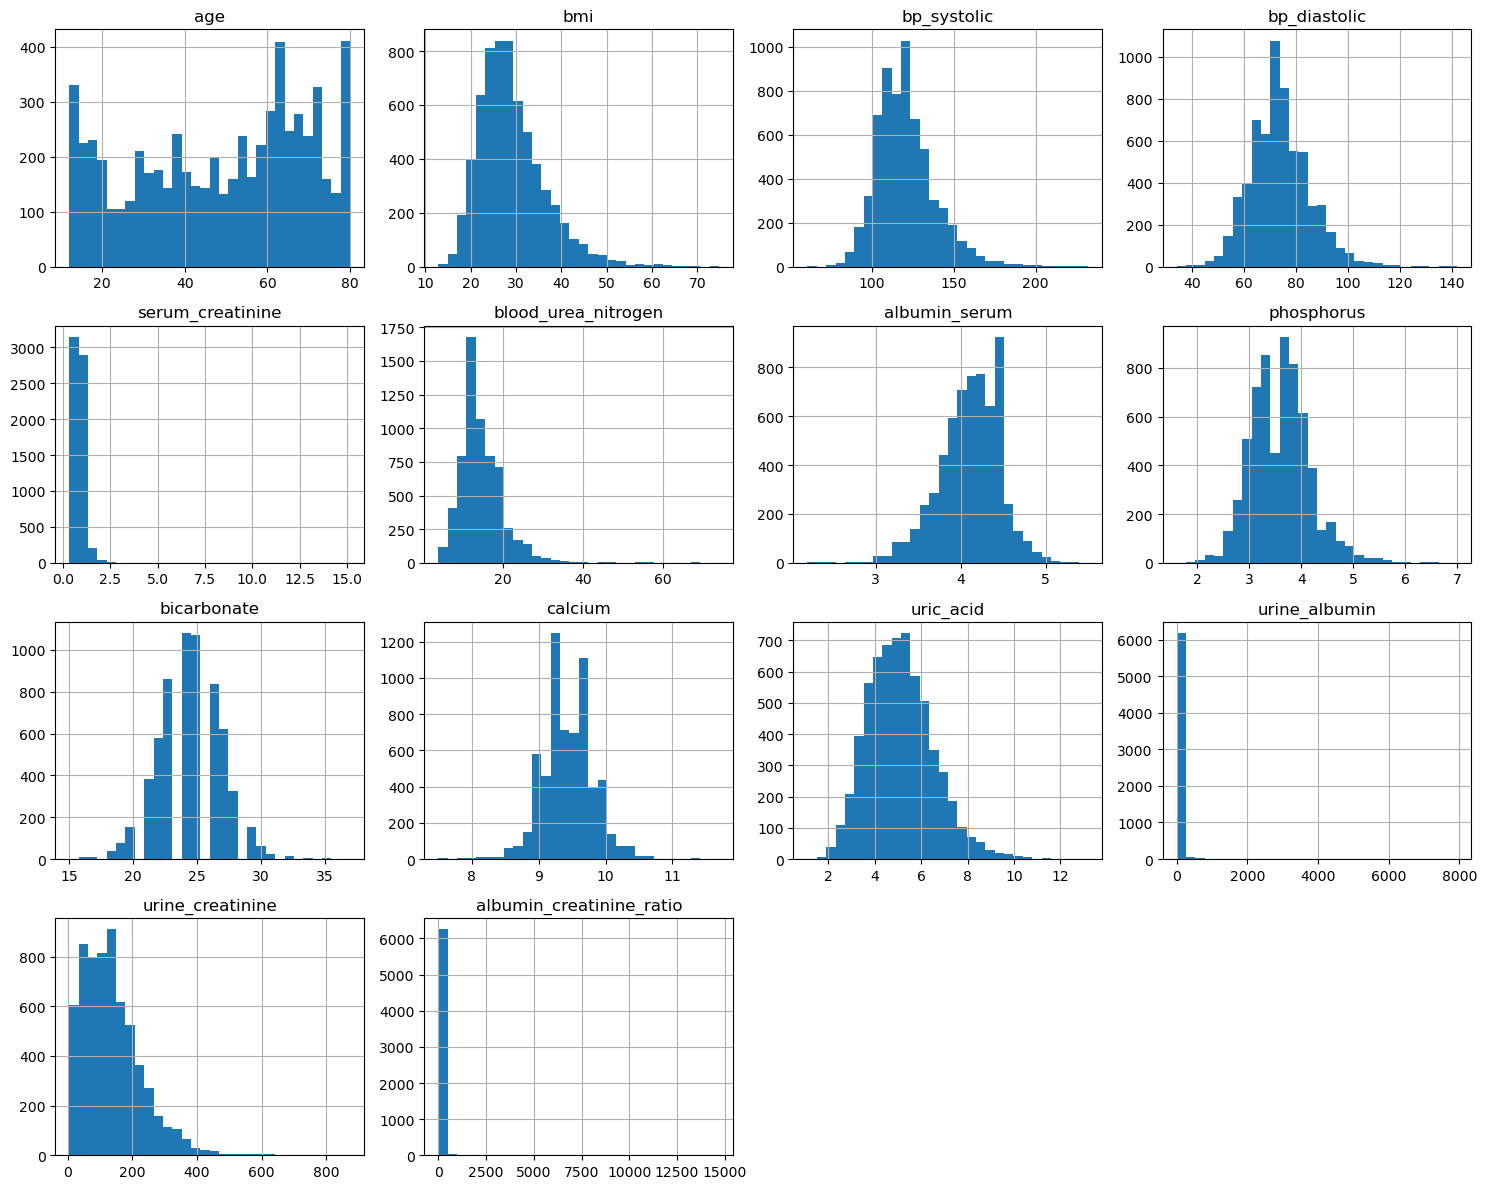

In [37]:
import matplotlib.pyplot as plt

numeric_cols = [
    'age', 'bmi', 'bp_systolic', 'bp_diastolic',
    'serum_creatinine', 'blood_urea_nitrogen',
    'albumin_serum', 'phosphorus', 'bicarbonate',
    'calcium', 'uric_acid',
    'urine_albumin', 'urine_creatinine',
    'albumin_creatinine_ratio'
]

complete_cohort[numeric_cols].hist(figsize=(15, 12), bins=30)
plt.tight_layout()
plt.show()

In [38]:
important_cols = [
    'serum_creatinine',
    'blood_urea_nitrogen',
    'albumin_creatinine_ratio',
    'urine_albumin',
    'albumin_serum'
]

print(
    complete_cohort.groupby('ckd_present')[important_cols].median()
)

             serum_creatinine  blood_urea_nitrogen  albumin_creatinine_ratio  \
ckd_present                                                                    
0                        0.74                 12.0                      7.04   
1                        0.97                 16.0                      9.95   

             urine_albumin  albumin_serum  
ckd_present                                
0                     8.60            4.2  
1                    11.36            4.1  


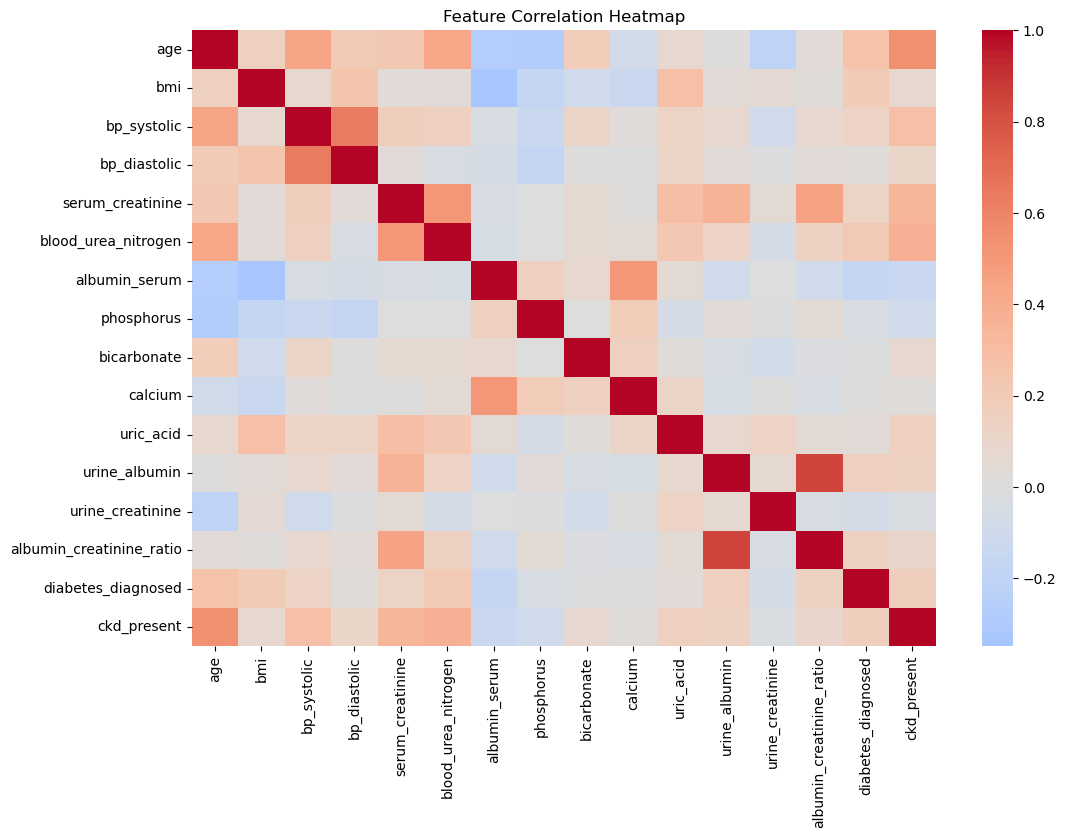

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = complete_cohort.select_dtypes(include='number').corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

In [40]:
features = [
    'age',
    'gender',
    'ethnicity',
    'bmi',
    'bp_systolic',
    'bp_diastolic',
    'serum_creatinine',
    'blood_urea_nitrogen',
    'albumin_serum',
    'phosphorus',
    'bicarbonate',
    'calcium',
    'uric_acid',
    'urine_albumin',
    'urine_creatinine',
    'albumin_creatinine_ratio',
    'diabetes_diagnosed'
]

X = complete_cohort[features]
y = complete_cohort['ckd_present']

print(X.shape)
print(y.shape)

(6303, 17)
(6303,)


In [41]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['gender', 'ethnicity']
numeric_cols = [col for col in features if col not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)

Training shape: (5042, 23)
Testing shape: (1261, 23)


In [46]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [47]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train_processed, y_train)

rf_pred = rf_model.predict(X_test_processed)
rf_prob = rf_model.predict_proba(X_test_processed)[:, 1]

print("Random Forest")
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_prob))

Random Forest
Accuracy : 0.9690721649484536
Precision: 0.9809885931558935
Recall   : 0.9467889908256881
F1 Score : 0.9635854341736695
ROC-AUC  : 0.9976039157398391


In [48]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    probability=True,
    random_state=42,
    class_weight='balanced'
)

svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)
svm_prob = svm_model.predict_proba(X_test_scaled)[:, 1]

print("SVM")
print("Accuracy :", accuracy_score(y_test, svm_pred))
print("Precision:", precision_score(y_test, svm_pred))
print("Recall   :", recall_score(y_test, svm_pred))
print("F1 Score :", f1_score(y_test, svm_pred))
print("ROC-AUC  :", roc_auc_score(y_test, svm_prob))

SVM
Accuracy : 0.9095955590800952
Precision: 0.9073724007561437
Recall   : 0.8807339449541285
F1 Score : 0.893854748603352
ROC-AUC  : 0.9617600328020093


In [49]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train_processed, y_train)

gb_pred = gb_model.predict(X_test_processed)
gb_prob = gb_model.predict_proba(X_test_processed)[:, 1]

print("Gradient Boosting")
print("Accuracy :", accuracy_score(y_test, gb_pred))
print("Precision:", precision_score(y_test, gb_pred))
print("Recall   :", recall_score(y_test, gb_pred))
print("F1 Score :", f1_score(y_test, gb_pred))
print("ROC-AUC  :", roc_auc_score(y_test, gb_prob))

Gradient Boosting
Accuracy : 0.9849325931800159
Precision: 0.9816849816849816
Recall   : 0.9834862385321101
F1 Score : 0.9825847846012832
ROC-AUC  : 0.9994336528112346


In [50]:
import pandas as pd

feature_names = preprocessor.get_feature_names_out()

importance = pd.DataFrame({
    'feature': feature_names,
    'importance': gb_model.feature_importances_
})

importance = importance.sort_values(
    by='importance',
    ascending=False
)

print(importance.head(15))

                          feature  importance
12          num__serum_creatinine    0.368938
8                        num__age    0.332625
21  num__albumin_creatinine_ratio    0.196288
1                cat__gender_Male    0.051722
0              cat__gender_Female    0.048645
20          num__urine_creatinine    0.000347
18                 num__uric_acid    0.000337
19             num__urine_albumin    0.000203
15                num__phosphorus    0.000170
17                   num__calcium    0.000139
16               num__bicarbonate    0.000136
9                        num__bmi    0.000119
14             num__albumin_serum    0.000099
13       num__blood_urea_nitrogen    0.000077
11              num__bp_diastolic    0.000073


In [ ]:
%pip install shap

In [52]:
import shap

explainer = shap.TreeExplainer(gb_model)

shap_values = explainer.shap_values(X_test_processed)

print(type(shap_values))

<class 'numpy.ndarray'>


In [53]:


feature_names = preprocessor.get_feature_names_out()

shap_importance = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    'mean_abs_shap',
    ascending=False
)

print(shap_importance.head(15))

                          feature  mean_abs_shap
12          num__serum_creatinine       2.741971
8                        num__age       1.951333
21  num__albumin_creatinine_ratio       1.180862
0              cat__gender_Female       0.955756
1                cat__gender_Male       0.932482
19             num__urine_albumin       0.032393
15                num__phosphorus       0.013738
10               num__bp_systolic       0.013364
14             num__albumin_serum       0.010310
11              num__bp_diastolic       0.009154
16               num__bicarbonate       0.007889
20          num__urine_creatinine       0.006885
13       num__blood_urea_nitrogen       0.006759
18                 num__uric_acid       0.003085
17                   num__calcium       0.002948


In [54]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    gb_model,
    X_train_processed,
    y_train,
    cv=cv,
    scoring='accuracy'
)

print("5-Fold Accuracy Scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())
print("Std:", cv_scores.std())

5-Fold Accuracy Scores: [0.97720515 0.99207136 0.98115079 0.98809524 0.98511905]
Mean Accuracy: 0.9847283181525006
Std: 0.005192412475322606


In [55]:
for metric in ['accuracy', 'f1', 'roc_auc']:
    scores = cross_val_score(
        gb_model,
        X_train_processed,
        y_train,
        cv=cv,
        scoring=metric
    )
    print(f"{metric.upper()}: {scores.mean():.4f} ± {scores.std():.4f}")

ACCURACY: 0.9847 ± 0.0052
F1: 0.9822 ± 0.0061
ROC_AUC: 0.9993 ± 0.0003


In [56]:
complete_cohort.to_csv(
    'D:/PROJECTS/4-1/nefroai/datasets/processed/CKD_NHANES_cleaned.csv',
    index=False
)

print("Cleaned dataset saved!")

Cleaned dataset saved!


In [58]:
import joblib

joblib.dump(gb_model, 'D:/PROJECTS/4-1/nefroai/model/gradient_boosting_model.pkl')
joblib.dump(preprocessor, 'D:/PROJECTS/4-1/nefroai/model/preprocessor.pkl')
joblib.dump(scaler, 'D:/PROJECTS/4-1/nefroai/model/scaler.pkl')

print("Models saved!")

Models saved!
